# Agrupamiento: k-centros y K-Means

En el notebook 01 convertimos un problema en una matriz $X$. En el 02 aprendimos a medir la
distancia entre dos renglones de $X$. Aquí usamos esas dos piezas para **descubrir grupos sin
usar las etiquetas**: aprendizaje no supervisado.



### Preparación

In [23]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans as sKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# baile: la libreria del curso
src = os.path.join(os.getcwd(), 'src')
if src not in sys.path:
    sys.path.append(src)
from SimpleClustering import Clustering, euclidiana, coseno, plotClusters, plotPCA

np.random.seed(0)

## 1. Aprendizaje no supervisado

El aprendizaje no supervisado es una técnica en la que un modelo aprende a identificar patrones y estructuras en un conjunto de datos sin necesidad de conocer la salida. Se parte de un conjunto de datos no etiquetados $X$; por lo general los datos son agrupados en categorías, donde cada grupo reúne a los objetos que presentan similitudes entre ellos. El aprendizaje no supervisado es ampliamente utilizado en áreas como el análisis de datos, la segmentación de mercado, y el reconocimiento de patrones.

La diferencia con lo que veremos en el notebook 05 es exactamente una columna: en aprendizaje
**supervisado** recibimos $X$ **y** $Y$; en **no supervisado** recibimos solo $X$. Las etiquetas de
Iris seguirán existiendo en estos ejemplos, pero **solo las usaremos para evaluar al final**,
nunca durante el agrupamiento.


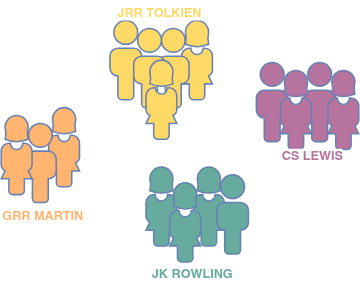

## 2. El problema de agrupamiento
El proceso de clustering o agrupamiento es un procedimiento de aprendizaje no supervisado utilizado para descubrir/explorar la estructura de una colección de
objetos. El objetivo es dividir el conjunto de objetos en grupos/clusters/clases de objetos **similares** mientras son separados de objetos **no similares**. Las clases generadas representan una generalización sobre los objetos y sus características.

Formalmente, el problema puede definirse como sigue: utilizando como entrada una colección de objetos $X$ y un valor entero $K$ se debe obtener un conjunto $G=\{G_1,G_2,...,G_K\}$. Donde cada objeto  $x_i \in X$ es un vector definido en $\mathbb{R}^N$,  se cumple que  $1 < K \leq |X|$. Al finalizar el proceso cada elemento $x_i$ debe pertenecer a uno de los grupos en $G$

#### Definiciones adicionales
- $m_k$ es el número de elementos en el grupo $G_k$, es decir $m_k=|G_k|$
- $c_k$ será utilizado para referirse al representante de todos los elementos en $G_k$, el cual puede ser:
    - la media geométrica $$c_k = \frac{1}{m_k} \sum_{i=1}^{m_k} x_i $$
    - la mediana
    - uno de los elementos en el grupo (**centro**)

  Esta última opción es la que distingue a los $k$-**centros** de K-**Means**: un *centro* es un elemento real de la colección, un *centroide* es un punto promedio que casi nunca coincide con ningún dato.
- Se utilizará $M$ para hacer referencia al conjunto de centroides $\{c_1,c_2,...,c_k\}$.
- En el problema de clustering a considerar cada objeto $x_i$ solo pertenece a un grupo, por lo tanto  para cualquier par de grupos  $G_A, G_B$ donde $A \neq B$, se cumple que:
$$G_A \cap G_B = \emptyset$$.



## 3. Los datos con los que vamos a trabajar

Usaremos dos conjuntos a lo largo del notebook:

- **blobs**: puntos generados con distribuciones gaussianas, en dos dimensiones. Sabemos la
  respuesta correcta por construcción, así que sirve para verificar que un algoritmo funciona.
- **iris**: datos reales de cuatro dimensiones, ya conocido de los notebooks 01 y 02.


In [2]:
# Tres grupos bien definidos, 100 puntos cada uno
blobs_centers = [[-4, 4], [-2, -4], [4, 0]]
blobs_data, blobs_labels = make_blobs(n_samples=300, centers=blobs_centers,
                                      random_state=0, cluster_std=[1.7, 1.8, 1.2])
blobs_classes = {int(l): c for l, c in zip(sorted(set(blobs_labels)), blobs_centers)}
print('blobs:', blobs_data.shape)
blobs_classes

blobs: (300, 2)


{0: [-4, 4], 1: [-2, -4], 2: [4, 0]}

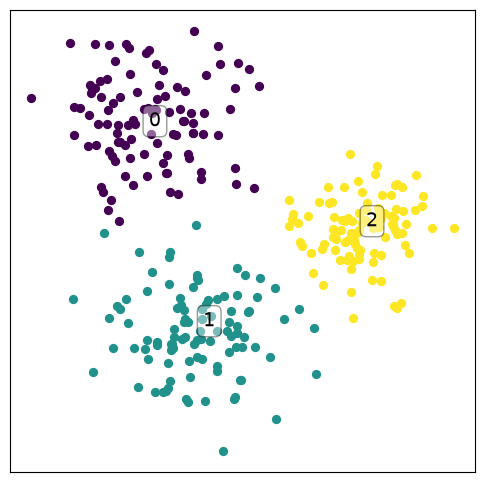

In [3]:
# plotClusters esta definida en src/SimpleClustering.py
plotClusters(blobs_data, blobs_labels, centroids=blobs_classes)

In [4]:
iris = load_iris()
data_iris, target_iris = iris['data'], iris['target']

# Centroide real de cada especie (usando las etiquetas, solo para ilustrar)
centers_iris = {l: np.mean(data_iris[target_iris == l], axis=0) for l in [0, 1, 2]}
for l, c in centers_iris.items():
    print('%-12s' % iris.target_names[l], np.round(c, 2))

setosa       [5.01 3.43 1.46 0.25]
versicolor   [5.94 2.77 4.26 1.33]
virginica    [6.59 2.97 5.55 2.03]


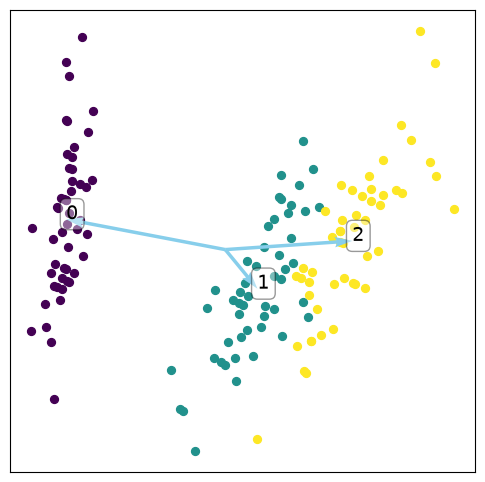

In [5]:
# iris tiene 4 dimensiones: plotPCA las proyecta a 2 para poder graficarlas
plotPCA(data_iris, target_iris, centroids=centers_iris, d=2)

Como mencionamos el proceso de clustering es una tarea de exploración de datos, lo cual implica que normalmente no se cuenta con información relativa a los resultados esperados del análisis. Algunos de los resultados esperados podrían ser:

- El número de grupos $K$
- El tamaño de los grupos (número de elementos en cada cluster)
- La densidad de los grupos
- La posición de los clusters

Existen muchas tareas donde se aplica el proceso de clustering, las cuales van desde  aplicaciones de recuperación de información, biología, medicina, negocios, entre otros.

Podemos resumir el proceso de clustering como sigue:

1. Definición del dominio, lo cual implica:
    - identificar los objetos a analizar
    - determinar el propósito de generar grupos
    - el conjunto de características que describen los objetos
2. Definir una función de comparación, es decir como se determina que tan parecidos son los objetos
3. Definir cómo medir la calidad de los grupos encontrados.
4. Determinar el algoritmo de clustering a utilizar

Fíjate en que los pasos 1 y 2 de esa lista son, literalmente, los notebooks 01 y 02. El paso 3
es la sección 4 de este notebook y el paso 4 son las secciones 6 y 7.


## 4. Recordando algunas medidas de distancia y similitud

Una vez definido el dominio del problema es necesario contar con un mecanismo para comparar los objetos en la colección. Lo anterior con la finalidad de decir qué tan similares o distantes son un objeto $x_i$ y otro $x_j$. Como ya hemos visto en la sección anterior, para comparar objetos definidos en un espacio vectorial, se puede utilizar una función de distancia $d$ o bien una función de similitud $\mathit{sim}$. Distancia y similitud están relacionados, desde que dos objetos que están a una distancia pequeña se puede decir que son similares.  En la siguiente tabla se resumen algunas de las funciones de distancia reportadas en la literatura:

|Nombre|Función &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;|
|:--:|:--:|
|Minkowski | $$L_q(x_i,x_j)=\sqrt[q]{\sum_{k=1}^N |x_{ik}-x_{jk}|^q}$$|
|**Coseno** (simulitud)   | $$\cos(x_i,x_j)=\frac{\sum_{k=1}^N x_{ik}*x_{jk}}{\sqrt{\sum_{k=1}^N x_{ik}^2} \sqrt{\sum_{k=1}^N x_{jk}^2}}$$|
**Coseno** (distancia)   | $$dcos(x_i,x_j)=1-\cos(x_i,x_j)$$|
|Divergencia de Kullback-Liebler| $$kld(x_i,x_j)=\sum_{k=1}^N x_{ik}* \log{\frac{x_{ik}}{x_{jk}}}$$|

> **Recordatorio del notebook 02.** Antes de agrupar, revisa la escala de tus características.
> Vimos que medir el sépalo en milímetros en lugar de centímetros cambia el vecino más cercano del
> **61%** de las flores de Iris. Los tres algoritmos de este notebook son distancias más un
> `argmin`, así que ese problema los afecta a todos.


In [7]:
# Cuanto pesa cada caracteristica de iris en la distancia euclidiana
rangos = data_iris.max(axis=0) - data_iris.min(axis=0)
for nombre, r in zip(iris.feature_names, rangos):
    print('%-20s rango = %.1f cm' % (nombre, r))
print()
print('petal length domina: su rango es %.1f veces el de sepal width'
      % (rangos[2] / rangos[1]))

sepal length (cm)    rango = 3.6 cm
sepal width (cm)     rango = 2.4 cm
petal length (cm)    rango = 5.9 cm
petal width (cm)     rango = 2.4 cm

petal length domina: su rango es 2.5 veces el de sepal width


## 5. Medidas de calidad

Evaluar si un agrupamiento $G$ es **"bueno"** o no, no es una tarea simple, desde que no existe un criterio definitivo para determinarlo. Sin embargo se han propuesto muchos criterios de evaluación, los cuales podemos dividir en externos e internos.

### 5.1 Medidas internas

Este tipo de medidas evalúan que tan compactos son los clusters mediante el uso de una medida de similitud o distancia. Esta clase de métricas generalmente intentan medir la cohesión en cada cluster (intra-cluster), la separación de los diferentes clusters (inter-cluster) o bien una combinación de ambas. Algunos ejemplos son:

#### SSE o inercia

SSE es la medida más simple y consiste en calcular la suma de la distancia de todos los objetos con respecto de los centroides de sus respectivos grupos. Se calcula mediante la siguiente fórmula:

$$\mathit{SSE} = \sum_{k=1}^{K} \sum_{\forall x_i \in G_k} d(x_i,c_k)^2$$

donde $G_k$ es el $k$-ésimo cluster y $c_k$ es el centroide del grupo. Como $x_i$ y $c_k$ son vectores, el cuadrado se toma sobre la **distancia** entre ambos. SSE es una forma simple de medir qué tan diferentes son los elementos de un cluster respecto de su centro geométrico. Esta medida permite maximizar la similitud entre objetos en el mismo grupo mediante la minimización del SSE.


Calcularlo es de una línea, y conviene tenerlo a la mano porque lo usaremos para verificar
tu implementación en la sección 8 y para el método de Elbow en la sección 9.


In [8]:
def sse(datos, centroides, distancia=euclidiana):
    """Suma de las distancias AL CUADRADO de cada elemento a su centroide MAS CERCANO.

    centroides: diccionario {id_cluster: vector}, como el atributo centroids_.
    """
    total = 0.0
    for x in datos:
        d = min(distancia(c, x) for c in centroides.values())  # <- el mas cercano
        total += d ** 2                                        # <- al cuadrado
    return total

print('SSE de los blobs usando los centros verdaderos: %.2f'
      % sse(blobs_data, blobs_classes))

SSE de los blobs usando los centros verdaderos: 1495.30


#### Coeficiente de silueta

El coeficiente de silueta trata de minimizar la distancia intracluster mientras maximiza la distancia inter-cluster. El coeficiente $\mathit{sil}(G)$  para un conjunto de clusters $G$ se determina como sigue:

1. Para un  elemento  $x_i \in G_A$ su distancia promedio $a_i$ con respecto de todo los elementos en su mismo cluster se cálcula como sigue:

$$a_i=\frac{1}{m_A-1}\sum_{\forall_{x_j} \in G_A} d(x_i,x_j)$$

2. Se calcula la mínima distancia promedio $b_i$ respecto a los elementos de los clusters a los que **no** pertenece $x_i$

$$b_i=\min_{G_B \neq G_A}\frac{1}{m_B}\sum_{\forall_{x_j} \in G_B} d(x_i,x_j)$$

3. Con el fin de tratar de maximizar la separación entre $x_i$ y los elementos que no están en su mismo grupo, mientras se minimiza la distancia promedio con los que se encuentran en su mismo grupo; se realiza el siguiente cociente:

$$\mathit{sil}(x_i)=\frac{b_i-a_i}{\max(a_i,b_i)}$$

4. Se promedia el coeficiente sobre todos los elementos de un mismo cluster

$$\mathit{sil}(G_k)= \frac{1}{m_k} \sum_{x_i} \mathit{sil}(x_i)$$

5. Finalmente se promedian los coeficientes de cada grupo para obtener el coeficiente global

$$\mathit{sil}(G)= \frac{1}{K} \sum_{k=1}^K \mathit{sil}({G_k})$$

Esta métrica tiene un costo mucho mayor que el SSE, ya que en el peor caso requiere conocer la distancia entre todos los elementos de la colección: es la matriz $R$ de $n \times n$ del notebook 02, que no es factible para colecciones muy grandes.

El coeficiente vive en $[-1,1]$. Un valor cercano a **1** indica que el elemento está mucho más cerca de su propio grupo que del vecino; cerca de **0**, que está en la frontera; **negativo**, que probablemente está en el grupo equivocado.



In [9]:
from sklearn.metrics import silhouette_samples

s = silhouette_samples(blobs_data, blobs_labels)
print('silueta global: %.3f' % s.mean())
print('elementos con silueta negativa (mal asignados): %d de %d' % ((s < 0).sum(), len(s)))

silueta global: 0.627
elementos con silueta negativa (mal asignados): 4 de 300


### 5.2 Medidas externas

Las medidas externas requieren que se conozcan a priori el número de grupos, así como la pertenencia de los elementos a cada uno de ellos. Algunas de las medidas que pueden utilizarse son $\mathit{precision}$, $\mathit{recall}$ y $F_1$. Si recordamos:

$$\mathit{recall}=\frac{tp}{tp+fn}$$

$$\mathit{precision}=\frac{tp}{tp+fp}$$

$$F_1=2 \frac{precision \cdot recall}{precision + recall}$$


En el contexto de clustering, dado un grupo $G_k$:

- $tp$ (verdaderos positivos): elementos asignados a $G_k$ que **sí** pertenecen a $G_k$.
- $fp$ (falsos positivos): elementos asignados a $G_k$ que **no** pertenecen a él.
- $fn$ (falsos negativos): elementos que pertenecen a $G_k$ pero fueron asignados a otro cluster.

Hay un detalle importante: el algoritmo de agrupamiento **no conoce los nombres de las clases**. Puede encontrar exactamente los grupos correctos y numerarlos al revés. Por eso, antes de calcular precisión y recall hay que emparejar cada cluster con la clase que mejor le corresponda, y por eso en la práctica se prefiere el índice que se describe a continuación, que ya es invariante a las permutaciones.

### 5.3 Índice Rand Ajustado (ARI)

De forma breve, ARI mide las similitudes de las particiones de dos asignaciones diferentes, ignorando las posibles permutaciones y ajustando la puntuación cerca de los valores 0 cuando las particiones se generan al azar. La versión no ajustada del índice Rand (RI) se describe mediante la siguiente fórmula:

$$\mathit {RI} = \frac{a + b}{C_2 ^ {n}},$$

donde $C_2 ^{n}$ es el número total de pares que se pueden formar a partir de una base de datos de tamaño $n$, es decir, ${n} \choose{2}$. Sea $T$ el conjunto de particiones "reales" (ground truth) y  $P$ el conjunto de particiones creado por el algoritmo de clustering, $a$ el número de pares que pertenecen al mismo grupo tanto en $T$ como en $P$ y $b$ el número de pares que están en diferentes particiones tanto $P$ como en $T$. La versión ajustada (ARI) se define mediante la siguiente  ecuación:

$$\mathit{ARI} = \frac{\mathit{RI}-E[\mathit{RI}]}{\max ({\mathit{RI}})-E[\mathit{RI}]},$$

donde $E$ es el valor esperado.

Estas y otras métricas de calidad de clustering ya están implementadas en `sklearn.metrics` https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics

En resumen, y esta es la regla práctica:

| Medida | ¿Necesita las etiquetas verdaderas? | Sirve para |
|---|---|---|
| SSE (inercia) | no | comparar valores de $K$ del mismo algoritmo (Elbow) |
| Silueta | no | comparar $K$ y comparar algoritmos distintos |
| $F_1$ | sí | evaluar contra una verdad conocida, tras emparejar clusters |
| ARI | sí | lo mismo, sin preocuparse por las permutaciones |

En un problema real casi nunca tienes las etiquetas: si las tuvieras, no estarías agrupando.
Las medidas externas se usan sobre todo **para validar el método** en datos donde sí conoces la
respuesta, como los blobs o iris, y luego aplicarlo a ciegas donde no la conoces.


In [11]:
# Los blobs, evaluados contra su propia verdad: casi perfecto, como se espera
etiquetas_perfectas = blobs_labels
etiquetas_al_azar   = np.random.randint(0, 3, size=len(blobs_labels))

print('ARI agrupamiento perfecto : %.3f' % adjusted_rand_score(blobs_labels, etiquetas_perfectas))
print('ARI agrupamiento aleatorio: %.3f' % adjusted_rand_score(blobs_labels, etiquetas_al_azar))
print()
print('Ese ~0 del caso aleatorio es el "ajustado" del nombre: el indice de Rand sin ajustar')
print('daria un valor alto solo por azar.')

ARI agrupamiento perfecto : 1.000
ARI agrupamiento aleatorio: 0.004

Ese ~0 del caso aleatorio es el "ajustado" del nombre: el indice de Rand sin ajustar
daria un valor alto solo por azar.


## 6. Familias de algoritmos
Los diferentes algoritmos de clustering pueden ser divididos con respecto a como crean los grupos, esto es en si lo hacen de forma jerárquica o particional. Un algoritmo particional crea el conjunto de clusters dividiendo los objetos en grupos disjuntos, lo cual se puede realizar hasta obtener grupos con un único elemento. Mientras que los métodos jerárquicos permiten la existencia de sub-grupos, es decir grupos anidados.

Los **jerárquicos** no los veremos (puedes revisar el notebook 04); el resto de este notebook trata los **particionales**, y dentro de ellos los dos que implementarás: FFT y K-Means.

## 7. El problema de los $k$-centros

El problema de los $K$-Centros consiste en dado un número limitado de facilidades ($K$) encontrar la forma de ubicarlas de tal forma los usuarios más alejados tengan un coste mínimo para acceder a dichas facilidades. Como ejemplo suponga que hay $n$ personas en edad escolar, de las cuales conoce la ubicación de su vivienda. Se pretende construir $K$ escuelas, pero eligiendo las posiciones de tal forma  que la distancia $r$ que los niños más alejados tengan que recorrer para acudir a clase sea mínima. En este caso las distintas ubicaciones pueden verse como un conjunto de puntos en un espacio bidimensional. Para solucionar el problema deben elegirse las posiciones en las que debe construirse cada escuela minimizando la distancia máxima $r$.  

Si consideramos que los puntos que generamos previamente en los blobs corresponden a las posiciones de los habitantes y se quieren construir 3 escuelas; entonces una solución simple es ubicarlas en la posición correspondiente al centroide de cada nube de puntos:

|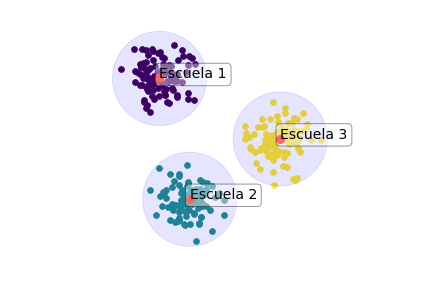|
|:---:|
|**Solución ideal para los $K$-centros cuando los datos siguen una distribución gaussiana**|

Desafortunadamente no todos los datos provienen de distribuciones normales con varianza unitaria. Por ejemplo, no es tan obvio utilizar la misma idea para los siguientes datos:


|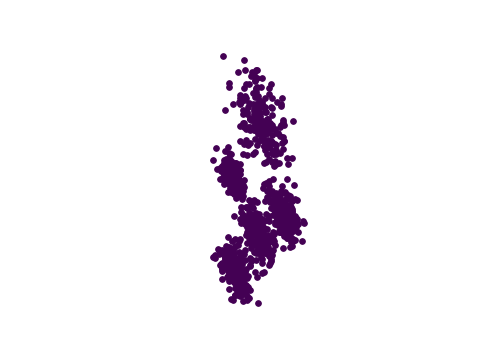|
|:----:|



Aun así podríamos utilizar $K$-Means para encontrar tres clusters y construir las escuelas en los centroides.

|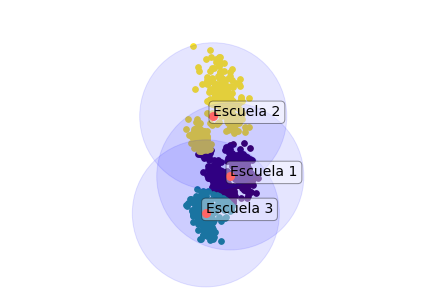|
|:----:|
|**Utilizando $K$Means para 100 ejecuciones se obtiene en promedio una distancia máxima de $r=37$ y un $SSE=128141.13$**|

Como puede observar en la figura $𝐾$-Means tiende a favorecer la zona más densa (ahí quedaron 2 escuelas). Lo cual podría ser bueno, ya que quiere decir que la mayoría de los estudiantes tienen que desplazarse poco, pero es muy probable que para este caso la distancia máxima no sea mínima.

Aquí está la idea central de toda la sección, y conviene enunciarla explícitamente porque es
lo que diferencia a los dos algoritmos que vas a implementar:

> **K-Means minimiza el promedio; los $k$-centros minimizan el máximo.**

Si el criterio es "que el alumno promedio camine poco", K-Means es lo correcto. Si el criterio es
"que **ningún** alumno camine más de $r$", que es como se redactan las normas reales de cobertura,
entonces hay que minimizar la distancia máxima, y ese es otro problema.


Para el caso en que se desea minimizar la distancia máxima resulta más conveniente resolver el problema mediante el uso de **Farthest First Traversal (FFT)**.

|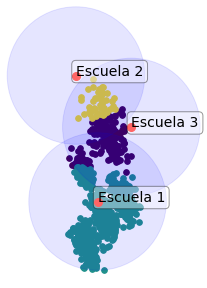|
|:----:|
|**Utilizando FFT para 100 ejecuciones se obtiene en promedio una distancia máxima de $r=33.38$ y un $SSE=24198.58$**|

### 7.1 Farthest First Traversal

FFT es un algoritmo que permite seleccionar $K$ centros de una colección de objetos. Un centro a diferencia de un centroide es un elemento que forma parte de la colección de datos. En FFT cada centro es seleccionado de tal forma que cualquier objeto $x_i \in X$ está a lo más  una distancia $r$ de uno de los centros. Al igual que $K$-Means, FFT es un algoritmo de particionado, solo que en este caso cada $G_k \in G$ será definido con base en la partición generada por los centros; utilizaremos $R_C$ para referirnos al conjunto de centros generados por el algoritmo.

Este algoritmo fue propuesto inicialmente por Teófilo González como una aproximación a la solución del problema de $K$-Centros, la cual es a lo más dos veces la solución óptima. Utilizando FFT podemos calcular un conjunto $R_C$ donde los centros $c_j \in R_C$ están lejanos entre sí. Esto se consigue simulando un recorrido, donde en cada iteración $k$, $c_k$ es seleccionado como el elemento más alejado de los elementos ya seleccionados. Sea  $r_k$ la distancia utilizada para seleccionar el centro $c_k$, entonces en la iteración $k$ se cumple que:

- Cualquier par de **centros** $c_i,c_j \in R_C$ se encuentran al menos a distancia $r_k$ el uno del otro.
- Cualquier elemento $x_i \in X$ se encuentra a lo más a distancia $r_k$ de uno de los centros $c_j \in R_C$ (cada elemento se asigna a la partición de su centro más cercano)

Para facilitar la definición del algoritmo definimos $d_{\min}(x)$ como la distancia entre un elemento $x$ y su centro más cercano en $R_C$, entonces:
$$d_{\min}(x)=\min\{d(x,c) \mid c \in R_C\}$$

------
**Algoritmo Farthest First Traversal**


------
1. $c_1 \gets x_i$, donde $x_i$ es seleccionado aleatoriamente de $X$
2. $R_C \gets \{c_1\}$
3. **Mientras** $|R_C|<K$
4. &nbsp;&nbsp;&nbsp;&nbsp; $c_n \gets \arg\max\{d_{\min}(x) \mid x \in X \setminus R_C\}$
5. &nbsp;&nbsp;&nbsp;&nbsp; $r \gets \max\{d_{\min}(x) \mid x \in X \setminus R_C\}$
6. &nbsp;&nbsp;&nbsp;&nbsp; $R_C \gets R_C \cup \{c_n\}$
7. $G \gets \{G_1,G_2,...G_k\}$
------
------

donde cada $G_k$ es el conjunto de los elementos $x_i$ que tienen como centro más cercano a $c_k$.

La siguiente figura muestra la evolución de algoritmo FFT, puede observarse que la distancia máxima disminuye a cada iteración; asi como el orden en que se eligen los puntos.

|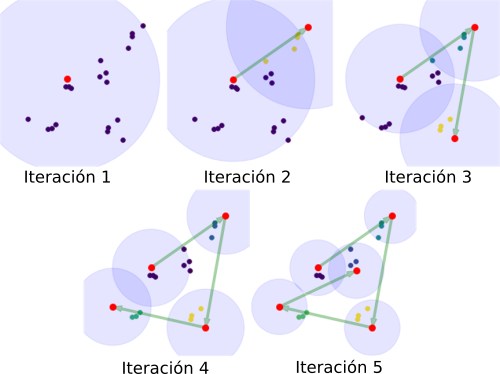|
|:----:|
|**FFT para $K=5$ sobre 5 nubes de puntos generadas asumiendo una distribución normal**|

FFT tiene la ventaja adicional que su complejidad está acotada por $O(D K n)$ donde $D$ es la dimensión de los datos, $n$ el número de elementos en la base de datos y $K$ el número de centros. La solución mencionada es la mejor solución conocida para el problema. Por otro lado, la solución obtenida es a lo más 2 veces la solución óptima. Si utilizamos $K$-Means el costo es $O(K D n I)$, donde $I$ es el número de iteraciones.  Finalmente hay que notar que los dos algoritmos optimizan cantidades **diferentes**: FFT minimiza la distancia máxima de los datos a uno de los centros, mientras que $K$-Means minimiza el error cuadrático $SSE$. Compararlos con una sola medida es, por lo tanto, injusto para alguno de los dos.  

## 8. La plantilla `Clustering`

Los dos algoritmos se implementan sobre la clase `Clustering` de `src/SimpleClustering.py`. La
plantilla ya trae resuelto todo lo que **no** es el algoritmo:

| Método | Qué hace | ¿Ya está hecho? |
|---|---|---|
| `_nearest_centroid(x)` | devuelve `(distancia, id)` del centroide más cercano a `x` | sí |
| `_assign_nearest_centroids()` | llena `labels_` asignando cada punto a su centroide | sí |
| `_inertia()` | calcula `inertia_`, el SSE | sí |
| `fit(data)` | guarda los datos y llama al algoritmo elegido | sí |
| `predict(data)` | asigna cluster a datos nuevos | sí |
| `randomClustering()` | ejemplo de referencia | sí |
| `FFTraversal()` | **Farthest First Traversal** | **tuyo** |
| `KMeans()` | **K-Means** | **tuyo** |

Tu trabajo se reduce a llenar un diccionario `self.centroids_` de la forma
`{0: vector, 1: vector, ...}` y llamar a los métodos que ya existen.


In [12]:
import inspect
print(inspect.getsource(Clustering.randomClustering))

    def randomClustering(self):
         # seleccionamos K elmentos distintos de forma aleatoria.
         # replace=False evita elegir dos veces el mismo elemento, que daría
         # menos de K clusters
         idx=np.random.choice(self.data.shape[0], self.n_clusters, replace=False)
         # diccionario {id_cluster: vector}, con los ids 0..K-1 como en scikit-learn
         self.centroids_=dict(enumerate(self.data[idx,:]))
         self._assign_nearest_centroids() #asignamos las etiquetas
         self._inertia() # calculamos el SSE
         return self



`randomClustering` es el ejemplo de referencia y equivale a **la primera iteración de K-Means**:
elige $K$ elementos al azar como centroides y asigna cada punto al más cercano. Nada más. Es el
mínimo que tu implementación debe superar.

Tres detalles de esas seis líneas que vas a necesitar:

- `np.random.choice(n, K, replace=False)` elige $K$ índices **distintos**. Con `randint` se pueden
  repetir y terminarías con menos de $K$ grupos.
- `self.centroids_` es un diccionario con claves `0..K-1`, igual que en scikit-learn.
- Después de fijar los centroides hay que llamar a `_assign_nearest_centroids()` y a `_inertia()`.


In [ ]:
np.random.seed(0)
cl = Clustering(n_clusters=3, algorithm='randomClustering').fit(blobs_data)
print('SSE de randomClustering: %.2f' % cl.inertia_)
print('ARI contra la verdad   : %.3f' % adjusted_rand_score(blobs_labels, cl.labels_))
plotClusters(blobs_data, cl.labels_, centroids=cl.centroids_)

Corre la celda anterior varias veces. Verás que el resultado **cambia mucho** según qué tres
puntos salgan sorteados: a veces los tres caen en el mismo blob y el ARI se desploma. Esa
inestabilidad es exactamente el problema que FFT y K-Means resuelven, cada uno a su manera.


In [ ]:
# La misma inestabilidad, medida sobre 30 corridas
resultados = []
for s in range(30):
    np.random.seed(s)
    c = Clustering(n_clusters=3).fit(blobs_data)
    resultados.append((c.inertia_, adjusted_rand_score(blobs_labels, c.labels_)))
resultados = np.array(resultados)
print('SSE: min %.0f  max %.0f  (varia un factor de %.1f)'
      % (resultados[:,0].min(), resultados[:,0].max(),
         resultados[:,0].max() / resultados[:,0].min()))
print('ARI: min %.2f  max %.2f' % (resultados[:,1].min(), resultados[:,1].max()))

## 9. Pruebas para verificar tu implementación

Antes de pedirte que escribas los algoritmos, aquí tienes con qué comprobarlos. La función
`verificar` corre una batería de pruebas sobre cualquier algoritmo de la plantilla y te dice cuál
falla. Úsala mientras desarrollas: es más rápido que mirar gráficas.

Si el método todavía no está implementado, las pruebas se reportan como **pendientes** en lugar de
reventar, así que puedes ejecutar esta sección desde ahora.


In [16]:
def verificar(nombre_algoritmo, datos, K=3, etiquetas_verdaderas=None,
              distancia=euclidiana, centros_son_elementos=False, corridas=10):
    """Bateria de pruebas para un algoritmo de la plantilla Clustering.

    centros_son_elementos: True para FFT, donde cada centro debe ser un elemento real de X.
    """
    resultados = []
    def prueba(nombre, fn):
        try:
            ok, detalle = fn()
        except Exception as e:
            resultados.append((nombre, None, '%s: %s' % (type(e).__name__, e)))
        else:
            resultados.append((nombre, bool(ok), detalle))  # bool(): numpy.bool_ rompe 'is True'

    np.random.seed(0)
    modelo = Clustering(n_clusters=K, distance_function=distancia,
                        algorithm=nombre_algoritmo).fit(datos)

    # Si el metodo todavia no llena centroids_, no tiene caso seguir
    if not hasattr(modelo, 'centroids_'):
        print('=== %s, K=%d ===' % (nombre_algoritmo, K))
        print('[PEND. ] el metodo no dejo centroids_: falta implementarlo')
        return []

    prueba('devuelve %d centroides' % K,
           lambda: (len(modelo.centroids_) == K, 'obtuvo %d' % len(modelo.centroids_)))

    prueba('una etiqueta por elemento',
           lambda: (len(modelo.labels_) == len(datos), 'obtuvo %d de %d' % (len(modelo.labels_), len(datos))))

    prueba('las etiquetas son claves validas de centroids_',
           lambda: (set(modelo.labels_) <= set(modelo.centroids_.keys()),
                    'etiquetas: %s' % sorted(set(modelo.labels_))))

    prueba('ningun cluster vacio',
           lambda: (len(set(modelo.labels_)) == K,
                    'clusters no vacios: %d' % len(set(modelo.labels_))))

    prueba('predict() coincide con labels_',
           lambda: (np.array_equal(modelo.predict(datos), np.array(modelo.labels_)), ''))

    def _inercia():
        esperado = sse(datos, modelo.centroids_, distancia)
        return (np.isclose(modelo.inertia_, esperado),
                'inertia_=%.2f  SSE=%.2f' % (modelo.inertia_, esperado))
    prueba('inertia_ es el SSE', _inercia)

    if centros_son_elementos:
        def _son_datos():
            faltan = [i for i, c in modelo.centroids_.items()
                      if not np.any(np.all(np.isclose(datos, c), axis=1))]
            return (not faltan, 'centros que no son elementos de X: %s' % faltan)
        prueba('cada centro es un elemento de X', _son_datos)

    def _mejor_que_azar():
        propios, azar = [], []
        for s in range(corridas):
            np.random.seed(s)
            propios.append(Clustering(n_clusters=K, distance_function=distancia,
                                      algorithm=nombre_algoritmo).fit(datos).inertia_)
            np.random.seed(s)
            azar.append(Clustering(n_clusters=K, distance_function=distancia).fit(datos).inertia_)
        return (np.mean(propios) <= np.mean(azar),
                'SSE propio %.1f vs aleatorio %.1f' % (np.mean(propios), np.mean(azar)))
    prueba('mejora sobre randomClustering', _mejor_que_azar)

    if etiquetas_verdaderas is not None:
        def _ari():
            v = adjusted_rand_score(etiquetas_verdaderas, modelo.labels_)
            return (v > 0.6, 'ARI = %.3f' % v)
        prueba('recupera los grupos verdaderos (ARI > 0.6)', _ari)

    ancho = max(len(n) for n, _, _ in resultados)
    print('=== %s, K=%d ===' % (nombre_algoritmo, K))
    for nombre, ok, detalle in resultados:
        marca = {True: '  OK  ', False: 'FALLA ', None: 'PEND. '}[ok]
        print('[%s] %-*s  %s' % (marca, ancho, nombre, detalle))
    faltan = sum(1 for _, ok, _ in resultados if ok is not True)
    print('--- %d de %d pruebas pasan' % (len(resultados) - faltan, len(resultados)))
    return resultados

Comprobamos que la batería funciona corriéndola sobre `randomClustering`, que sí está
implementado. Debe pasar casi todo: es un algoritmo válido, solo que malo.


In [17]:
_ = verificar('randomClustering', blobs_data, K=3, etiquetas_verdaderas=blobs_labels)

=== randomClustering, K=3 ===
[  OK  ] devuelve 3 centroides                           obtuvo 3
[  OK  ] una etiqueta por elemento                       obtuvo 300 de 300
[  OK  ] las etiquetas son claves validas de centroids_  etiquetas: [0, 1, 2]
[  OK  ] ningun cluster vacio                            clusters no vacios: 3
[  OK  ] predict() coincide con labels_                  
[  OK  ] inertia_ es el SSE                              inertia_=5243.57  SSE=5243.57
[  OK  ] mejora sobre randomClustering                   SSE propio 4893.4 vs aleatorio 4893.4
[FALLA ] recupera los grupos verdaderos (ARI > 0.6)      ARI = 0.412
--- 7 de 8 pruebas pasan


Las dos últimas pruebas son las interesantes. "Mejora sobre randomClustering" se compara
consigo mismo, así que empata; y el ARI queda por debajo del umbral porque elegir tres puntos al
azar no recupera los grupos de forma confiable. **Tu implementación sí debe pasar esas dos.**


## 10. Ejercicio 1: implementa `FFTraversal`

Abre `src/SimpleClustering.py` y sustituye el cuerpo del método `FFTraversal` por tu
implementación del pseudocódigo de la sección 7.1.

```python
def FFTraversal(self):
    # 1. elegir c_1 al azar de self.data
    # 2. repetir hasta tener n_clusters centros:
    #        para cada x, calcular d_min(x) = distancia a su centro mas cercano
    #        el nuevo centro es el x que MAXIMIZA d_min(x)
    # 3. self.centroids_ = {0: c_1, 1: c_2, ...}
    # 4. self._assign_nearest_centroids()
    # 5. self._inertia()
    return self
```
Cuando termines, ejecuta la siguiente celda. Recuerda reiniciar el kernel o usar `%autoreload`
para que Python recargue el archivo modificado.


In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
_ = verificar('FFTraversal', blobs_data, K=3, etiquetas_verdaderas=blobs_labels,
              centros_son_elementos=True)

su implementación de Farthest First Traversal
=== FFTraversal, K=3 ===
[PEND. ] el metodo no dejo centroids_: falta implementarlo


In [20]:
# Cuando pase las pruebas, visualiza el resultado
try:
    np.random.seed(0)
    fft = Clustering(n_clusters=3, algorithm='FFTraversal').fit(blobs_data)
    plotClusters(blobs_data, fft.labels_, centroids=fft.centroids_)
except Exception as e:
    print('Pendiente de implementar:', type(e).__name__)

su implementación de Farthest First Traversal
Pendiente de implementar: AttributeError


## 11. K-Means

De los algoritmos particionales, sin duda el más conocido es $K$-Means.

Es un algoritmo basado en particionado. El algoritmo requiere como entrada la colección $X$ y el número de clusters $K$. El proceso comienza seleccionando $K$ elementos de $X$, los cuales son utilizados como los centroides iniciales. Posteriormente cada punto es asignado a su centroide más cercano, todos los elementos asignados a un mismo centroide forman un cluster. Una vez asignados todos los elementos se calcula el centroide $c_k$ de cada uno de los grupos. Se repite el proceso de asignación y actualización hasta que los centroides dejan de cambiar. Podemos resumir el algoritmo en el siguiente listado:

------
**Algoritmo básico para K-Means**


------
1. Seleccionar $K$ objetos de $X$ como centroides iniciales
2. **repetir**
3. &nbsp;&nbsp;&nbsp;&nbsp;Para cada $x_i \in X$ asignar $x_i$ al grupo representado por su centroide más cercano
4. &nbsp;&nbsp;&nbsp;&nbsp;Recalcular los centroides con base en los grupos obtenidos
5. **hasta** que los centroides no cambien
------
------


Para el paso 3 se utiliza alguna función de comparación, de distancia o de similitud. La tabla siguiente resume las combinaciones que **aseguran la convergencia** del método: fíjate en que el valor usado como centroide **depende de la distancia elegida**. Usar la media con distancia Manhattan, por ejemplo, no garantiza que el algoritmo converja.

   
|Función de comparación| valor para el centroide | Función objetivo &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;|
|:---:|:---:|:---:|
|Distancia Euclidiana| media|  $$\min \sum_{k=1}^{K}  \sum_{\forall x_i \in G_k} (x_i-c_k)^2$$|
|Distancia Manhattan | mediana|  $$\min \sum_{k=1}^{K} \sum_{\forall x_i \in G_k} |x_i-c_k|$$|
|Similitud Coseno    | media|  $$\max \sum_{k=1}^{K} \sum_{\forall x_i \in G_k} \cos(x_i-c_k)$$|

La siguiente figura muestra el proceso de convergencia del $K$-Means para un conjunto de 90 elementos y $K=3$ clusters:

|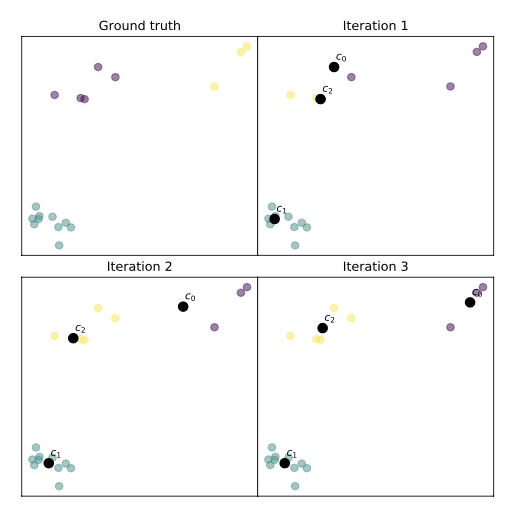|
|:--:|
|**Iteraciones $K$-Means**|

Compara los dos pseudocódigos, el de la sección 7.1 y el de arriba. La diferencia cabe en una
frase:

| | FFT | K-Means |
|---|---|---|
| Representante del grupo | un **centro**: un elemento real de $X$ | un **centroide**: el promedio del grupo |
| Cómo elige el siguiente | el punto **más lejano** a los ya elegidos (`argmax`) | promedia los puntos ya asignados |
| Iteraciones | exactamente $K-1$ | repite hasta converger |
| Qué optimiza | la distancia **máxima** ($r$) | el **SSE** (promedio) |
| Garantía | a lo más 2 veces el óptimo | óptimo local, depende de la inicialización |

Que K-Means solo garantice un óptimo **local** es la razón de que scikit-learn lo corra varias
veces con distintas inicializaciones (`n_init`) y se quede con el mejor resultado.


## 12. Ejercicio 2: implementa `KMeans`

Sustituye el cuerpo del método `KMeans` en `src/SimpleClustering.py`:

```python
def KMeans(self, max_iter=100):
    # 1. inicializar los centroides (puedes reusar randomClustering, o mejor: FFT)
    # 2. repetir hasta max_iter:
    #        asignar cada punto a su centroide mas cercano
    #        recalcular cada centroide como la media de los puntos asignados
    #        si ningun centroide cambio, terminar
    # 3. self._assign_nearest_centroids()
    # 4. self._inertia()
    return self
```

In [ ]:
_ = verificar('KMeans', blobs_data, K=3, etiquetas_verdaderas=blobs_labels)

In [ ]:
# Comparacion visual de los tres algoritmos, cuando los tengas implementados
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, alg in zip(axes, ['randomClustering', 'FFTraversal', 'KMeans']):
    try:
        np.random.seed(0)
        m = Clustering(n_clusters=3, algorithm=alg).fit(blobs_data)
        ax.scatter(blobs_data[:, 0], blobs_data[:, 1], c=m.labels_, cmap='viridis', s=20)
        centros = np.array(list(m.centroids_.values()))
        ax.scatter(centros[:, 0], centros[:, 1], c='red', marker='X', s=200, edgecolors='k')
        ax.set_title('%s\nSSE=%.0f  ARI=%.2f'
                     % (alg, m.inertia_, adjusted_rand_score(blobs_labels, m.labels_)))
    except Exception as e:
        ax.set_title('%s\n(pendiente)' % alg)
        ax.text(0.5, 0.5, type(e).__name__, ha='center', transform=ax.transAxes)
plt.tight_layout(); plt.show()

## 13. Determinando el número de clusters

Este problema ha sido objeto de muchos estudios, pero solo mencionaremos brevemente dos métodos de los muchos que existen en la literatura.

**Método de Elbow (codo)**: consiste en calcular el $SSE$ para valores consecutivos de $K$ y elegir aquel donde se da el mayor cambio de pendiente. El $SSE$ siempre disminuye al aumentar $K$ (con $K=n$ vale cero), así que no se busca el mínimo sino el punto donde deja de bajar rápido.

**Método de la silueta**: se calcula el coeficiente de silueta para cada $K$ y se elige el que presente el valor máximo. A diferencia del $SSE$, la silueta sí tiene un máximo interior, así que la lectura es menos subjetiva.

La siguiente gráfica muestra ambos criterios sobre el dataset de iris. Con el criterio de Elbow el valor óptimo sería $K=3$, mientras que con la silueta sería $K=2$.

|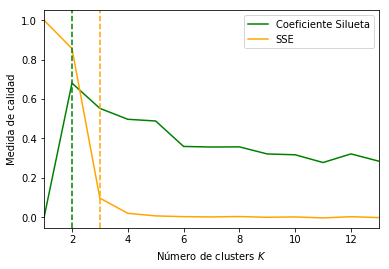|
|:----:|
|**Ejemplos de criterios de selección del valor de K para la DB Iris**|

Que los dos métodos den respuestas distintas **no es un error**, y vale la pena detenerse aquí
porque es el punto donde más podemos confundirnos.

La silueta dice $K=2$ porque, geométricamente, iris **tiene** dos grupos: setosa por un lado y
versicolor junto con virginica por el otro. Ya lo habíamos visto en el notebook 02, en la matriz
de distancias: el bloque de setosa era claramente separable y los otros dos se traslapaban.

El $K=3$ que buscamos viene de la **biología**, no de la geometría. Ninguna medida interna puede
descubrirlo, porque ninguna tiene acceso a esa información.

> **La lección**: estos métodos sugieren, no deciden. El número de grupos correcto depende del
> dominio del problema, y en la sección 1 de la lista de pasos (definición del dominio) es donde
> esa decisión se toma.

Reproduzcamos la gráfica. Usamos el K-Means de scikit-learn para que la celda corra aunque
todavía no tengas el tuyo; el ejercicio 3 te pide repetirla con tu implementación.


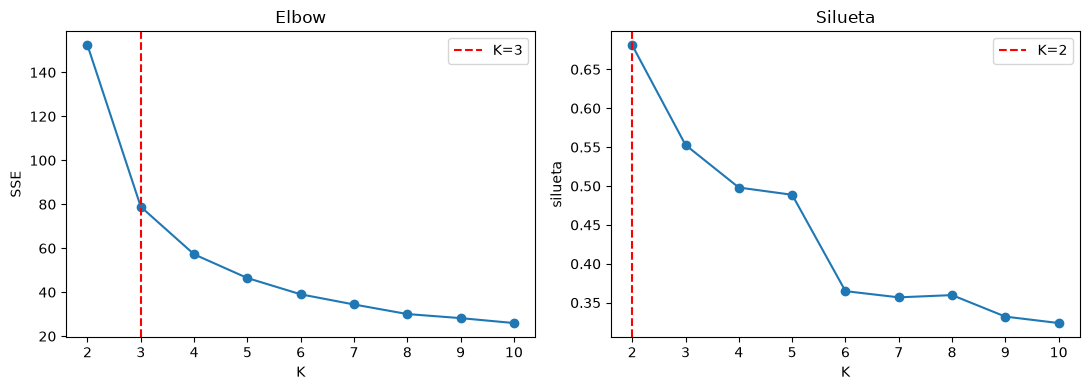

K con mayor silueta: 2


In [21]:
Ks = range(2, 11)
sses, siluetas = [], []
for K in Ks:
    km = skKMeans(n_clusters=K, n_init=10, random_state=0).fit(data_iris)
    sses.append(km.inertia_)
    siluetas.append(silhouette_score(data_iris, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(Ks), sses, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('SSE'); axes[0].set_title('Elbow')
axes[0].axvline(3, color='red', linestyle='dashed', label='K=3')
axes[0].legend()
axes[1].plot(list(Ks), siluetas, marker='o')
axes[1].set_xlabel('K'); axes[1].set_ylabel('silueta'); axes[1].set_title('Silueta')
axes[1].axvline(2, color='red', linestyle='dashed', label='K=2')
axes[1].legend()
plt.tight_layout(); plt.show()

print('K con mayor silueta: %d' % list(Ks)[int(np.argmax(siluetas))])

In [22]:
# Y el ARI contra las especies reales, para cerrar el argumento
for K in [2, 3, 4]:
    km = skKMeans(n_clusters=K, n_init=10, random_state=0).fit(data_iris)
    print('K=%d  silueta=%.3f  ARI contra las especies=%.3f'
          % (K, silhouette_score(data_iris, km.labels_),
             adjusted_rand_score(target_iris, km.labels_)))

K=2  silueta=0.681  ARI contra las especies=0.540
K=3  silueta=0.553  ARI contra las especies=0.730
K=4  silueta=0.498  ARI contra las especies=0.650


$K=2$ gana en silueta pero $K=3$ gana en ARI. La geometría prefiere dos grupos; la verdad
biológica son tres. Exactamente el punto anterior, ahora con números.


## 14. Ejercicio 3: comparación

Con tus dos implementaciones ya funcionando propon un conjunto de datos:

1. Repite la gráfica de Elbow y silueta de la sección 13 usando **tu** `KMeans` en lugar del de scikit-learn. ¿Obtienes las mismas conclusiones? Si no, ¿por qué?

2. Compara FFT y K-Means en las dos cantidades que cada uno optimiza:

   | | SSE (promedio) | radio $r$ (máximo) |
   |---|---|---|
   | FFT | | |
   | K-Means | | |

   Escribe el radio como $r = \max_i \min_k d(x_i, c_k)$. Predice quién gana en cada columna
   **antes** de correr el código, y explica el resultado.
3. Inicializa tu K-Means con los centros de FFT en lugar de puntos al azar. ¿Baja el SSE final?
   ¿Baja el número de iteraciones `n_iter_`? Esta idea, con una variante probabilística, es lo
   que scikit-learn llama `init='k-means++'`.
4. Repite todo con `coseno` en lugar de `euclidiana` (`Clustering(distance_function=coseno)`)?


In [70]:

for i in range(5):
    km=sKMeans(n_clusters=2, init="random", n_init=1, 
               random_state=i)
    km.fit(blobs_data)
    print(km.inertia_)

4155.808472154218
5489.520828831503
4155.808472154218
5489.520828831503
5489.520828831503


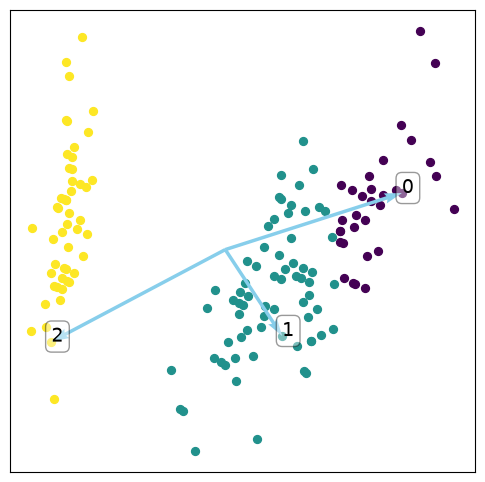

In [88]:
mc=Clustering(n_clusters=3, algorithm="randomClustering")
mc=mc.fit(data_iris)
plotPCA(data_iris, mc.predict(data_iris), centroids=mc.centroids_, d=2)

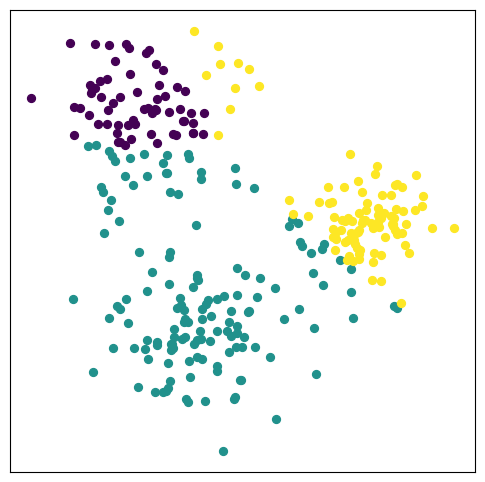